In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# =========================
# 1. Imports
# =========================
import os
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# =========================
# 2. Paths
# =========================

BASE_DATA_DIR = "/content/drive/MyDrive/Senior_Project/00_Data/cleaned/Final_Short_Form"
BERT_RESULTS_DIR = "/content/drive/MyDrive/Senior_Project/03_Results/BERT/Final_Short_Form_Probs"

OUT_DIR = "/content/drive/MyDrive/Senior_Project/03_Results/BERT/Final_Short_Form_Probs/results"
os.makedirs(OUT_DIR, exist_ok=True)

# Final test datasets
TEST_PATHS = {
    "liar": f"{BASE_DATA_DIR}/LIAR/test_liar.csv",
    "covid": f"{BASE_DATA_DIR}/COVID/test_covid.csv",
    "sensational": f"{BASE_DATA_DIR}/Sensational/test_sensational.csv",
    "baseline": f"{BASE_DATA_DIR}/LIAR+COVID/test_liar_covid.csv",
    "combined": f"{BASE_DATA_DIR}/Combined/test_combined.csv",
}

BERT_PRED_PATHS = {

    # BASELINE MODEL = trained on LIAR + COVID
    "baseline_model": {
        "combined": (
            f"{BERT_RESULTS_DIR}/bert_probs_baseline_model_on_combined_test.csv"),
        "covid": (
            f"{BERT_RESULTS_DIR}/bert_probs_baseline_model_on_covid_test.csv"),
        "baseline": (
            f"{BERT_RESULTS_DIR}/bert_probs_baseline_model_on_liar_covid_test.csv"),
        "liar": (
            f"{BERT_RESULTS_DIR}/bert_probs_baseline_model_on_liar_test.csv"),
        "sensational": (
            f"{BERT_RESULTS_DIR}/bert_probs_baseline_model_on_sensational_test.csv"),
    },
    # COMBINED MODEL = trained on full combined dataset
    "combined_model": {
        "combined": (
            f"{BERT_RESULTS_DIR}/bert_probs_full_model_on_combined_test.csv"),
        "covid": (
            f"{BERT_RESULTS_DIR}/bert_probs_full_model_on_covid_test.csv"),
        "baseline": (
            f"{BERT_RESULTS_DIR}/bert_probs_full_model_on_liar_covid_test.csv"),
        "liar": (
            f"{BERT_RESULTS_DIR}/bert_probs_full_model_on_liar_test.csv"),
        "sensational": (
            f"{BERT_RESULTS_DIR}/bert_probs_full_model_on_sensational_test.csv"),
    }
}

In [ ]:
# =========================
# Inspect one prediction file
# =========================

sample_model = "combined_model"
sample_dataset = "combined"

sample_pred = pd.read_csv(BERT_PRED_PATHS[sample_model][sample_dataset])

print("Sample prediction columns:")
print(sample_pred.columns.tolist())

sample_pred.head()

Sample prediction columns:
['combined_ID', 'is_fake', 'bert_prob_fake']


,combined_ID,is_fake,bert_prob_fake
0,9744,1,0.858658
1,7239,0,0.344053
2,213,1,0.146739
3,1464,1,0.177193
4,2710,0,0.196239


In [ ]:
# =========================
# 3. Helper functions
# =========================

def get_id_col(df):
    if "combined_ID" in df.columns:
        return "combined_ID"
    elif "liar_covid_ID" in df.columns:
        return "liar_covid_ID"
    elif "ID" in df.columns:
        return "ID"
    elif "id" in df.columns:
        return "id"
    else:
        raise ValueError(f"No ID column found. Columns: {df.columns.tolist()}")


def evaluate_predictions(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def check_alignment(test_df, pred_df, dataset_name, model_name):
    test_id_col = get_id_col(test_df)
    pred_id_col = get_id_col(pred_df)

    test_ids = set(test_df[test_id_col])
    pred_ids = set(pred_df[pred_id_col])

    ids_in_both = len(test_ids & pred_ids)
    only_test = len(test_ids - pred_ids)
    only_pred = len(pred_ids - test_ids)

    print(f"\nAlignment check: {model_name} → {dataset_name}")
    print("Test ID column:", test_id_col)
    print("Prediction ID column:", pred_id_col)
    print("Test rows:", len(test_df))
    print("Prediction rows:", len(pred_df))
    print("IDs in both:", ids_in_both)
    print("Only in test:", only_test)
    print("Only in predictions:", only_pred)

    aligned = (
        only_test == 0 and
        only_pred == 0 and
        len(test_df) == len(pred_df)
    )

    return aligned, test_id_col, pred_id_col

In [ ]:
# =========================
# 4. Inspect sample prediction file
# =========================

sample_df = pd.read_csv(BERT_PRED_PATHS["combined_model"]["combined"])

print(sample_df.columns.tolist())
sample_df.head()

['combined_ID', 'is_fake', 'bert_prob_fake']


,combined_ID,is_fake,bert_prob_fake
0,9744,1,0.858658
1,7239,0,0.344053
2,213,1,0.146739
3,1464,1,0.177193
4,2710,0,0.196239


In [ ]:
# =========================
# 5. Evaluate all BERT prediction files
# =========================

all_results = []
merged_outputs = {}

for model_name, pred_paths in BERT_PRED_PATHS.items():
    merged_outputs[model_name] = {}

    for dataset_name, pred_path in pred_paths.items():
        print("\n" + "=" * 80)
        print(f"Evaluating {model_name} on {dataset_name}")

        test_path = TEST_PATHS[dataset_name]

        test_df = pd.read_csv(test_path)
        pred_df = pd.read_csv(pred_path)

        aligned, test_id_col, pred_id_col = check_alignment(
            test_df=test_df,
            pred_df=pred_df,
            dataset_name=dataset_name,
            model_name=model_name
        )

        if not aligned:
            print("WARNING: alignment issue detected. Skipping this file.")
            continue

        if "bert_prob_fake" not in pred_df.columns:
            raise ValueError(f"Missing bert_prob_fake column in {pred_path}")

        # Merge prediction probabilities back to original test dataset
        merged = test_df.merge(
            pred_df[[pred_id_col, "bert_prob_fake"]],
            left_on=test_id_col,
            right_on=pred_id_col,
            how="inner"
        )

        # Convert probability to prediction for BERT-only evaluation
        merged["bert_pred"] = (merged["bert_prob_fake"] >= 0.5).astype(int)

        y_true = merged["is_fake"].astype(int)
        y_pred = merged["bert_pred"].astype(int)

        metrics = evaluate_predictions(y_true, y_pred)

        result = {
            "bert_model": model_name,
            "test_dataset": dataset_name,
            "test_rows": len(test_df),
            "prediction_rows": len(pred_df),
            "merged_rows": len(merged),
            "id_col_test": test_id_col,
            "id_col_pred": pred_id_col,
            "threshold": 0.5,
            **metrics
        }

        all_results.append(result)
        merged_outputs[model_name][dataset_name] = merged

        print("\nMetrics:")
        for k, v in metrics.items():
            print(f"{k}: {v}")

        print("\nProbability summary:")
        print(merged["bert_prob_fake"].describe())

        print("\nClassification report:")
        print(classification_report(y_true, y_pred, zero_division=0))


Evaluating baseline_model on combined

Alignment check: baseline_model → combined
Test ID column: combined_ID
Prediction ID column: combined_ID
Test rows: 4322
Prediction rows: 4322
IDs in both: 4322
Only in test: 0
Only in predictions: 0

Metrics:
accuracy: 0.8037945395650162
precision: 0.8026775320139697
recall: 0.7304025423728814
f1: 0.7648363838047698
tn: 2095
fp: 339
fn: 509
tp: 1379

Probability summary:
count    4322.000000
mean        0.430749
std         0.372819
min         0.001827
25%         0.051924
50%         0.354993
75%         0.792952
max         0.996882
Name: bert_prob_fake, dtype: float64

Classification report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      2434
           1       0.80      0.73      0.76      1888

    accuracy                           0.80      4322
   macro avg       0.80      0.80      0.80      4322
weighted avg       0.80      0.80      0.80      4322


Evaluating baseline_model on

In [ ]:
bert_results_df = pd.DataFrame(all_results)

import matplotlib.pyplot as plt

In [ ]:
bert_results_df.head()

,bert_model,test_dataset,test_rows,prediction_rows,merged_rows,id_col_test,id_col_pred,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
0,baseline_model,combined,4322,4322,4322,combined_ID,combined_ID,0.5,0.803795,0.802678,0.730403,0.764836,2095,339,509,1379
1,baseline_model,covid,1920,1920,1920,ID,ID,0.5,0.977604,0.985330,0.962963,0.974018,1071,12,31,806
2,baseline_model,baseline,4079,4079,4079,liar_covid_ID,liar_covid_ID,0.5,0.784261,0.808629,0.657612,0.725343,2037,275,605,1162
3,baseline_model,liar,2160,2160,2160,ID,ID,0.5,0.687037,0.686765,0.502151,0.580124,1017,213,463,467
4,baseline_model,sensational,242,242,242,ID,ID,0.5,0.466942,0.481818,0.876033,0.621701,7,114,15,106


In [ ]:
# safe df to csv, order best to worst f1
bert_results_df = bert_results_df.sort_values(by="f1", ascending=False)
bert_results_df.to_csv(os.path.join(OUT_DIR, "bert_results.csv"), index=False)

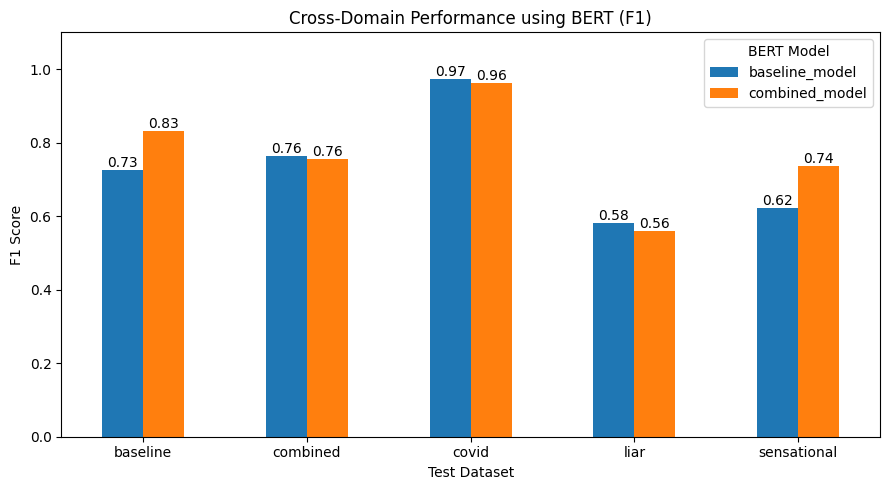

In [ ]:
# =========================
# 8. Visual 1: BERT F1 by test dataset
# =========================

pivot_f1 = bert_results_df.pivot(
    index="test_dataset",
    columns="bert_model",
    values="f1"
)

ax = pivot_f1.plot(kind="bar", figsize=(9, 5))
ax.set_title("Cross-Domain Performance using BERT (F1)")
ax.set_ylabel("F1 Score")
ax.set_xlabel("Test Dataset")
ax.set_ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title="BERT Model")

# Add F1 scores on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge')

plt.tight_layout()
plt.show()

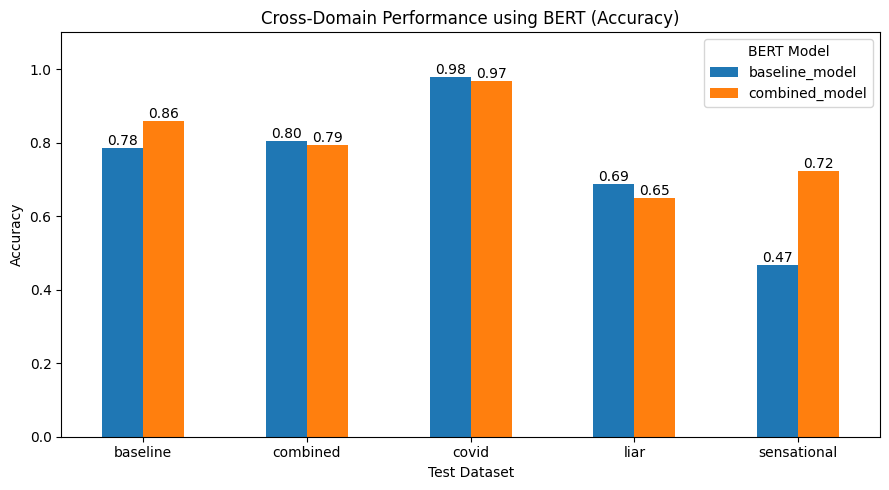

In [ ]:
# =========================
# 9. Visual 2: BERT Accuracy by test dataset
# =========================

pivot_acc = bert_results_df.pivot(
    index="test_dataset",
    columns="bert_model",
    values="accuracy"
)

ax = pivot_acc.plot(kind="bar", figsize=(9, 5))
ax.set_title("Cross-Domain Performance using BERT (Accuracy)")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Test Dataset")
ax.set_ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title="BERT Model")

# Add F1 scores on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge')

plt.tight_layout()
plt.show()